In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

# оценка моделей
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_predict

# метрики
from sklearn.metrics import mean_squared_error
from sklearn.metrics import roc_auc_score, roc_curve

# модели
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import catboost
import xgboost

# Подавление предупреждений
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

# Переобучение и методы борьбы с ним

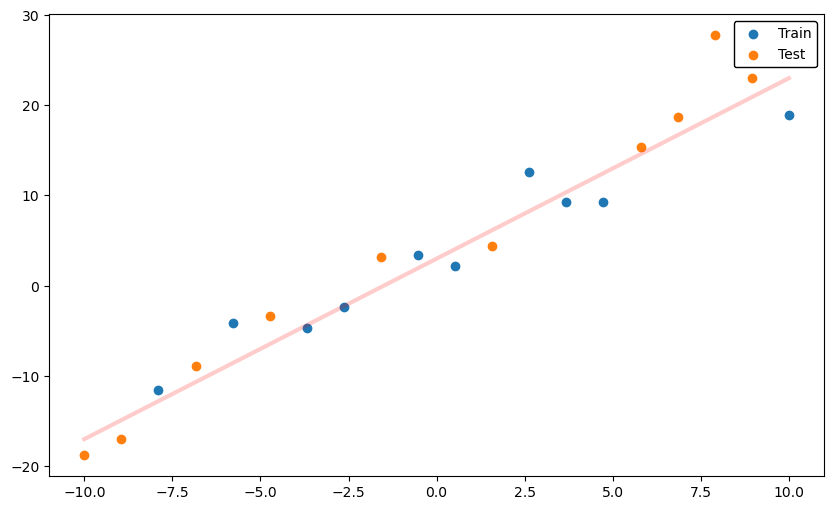

In [98]:
3# Генерируем искусственные данные из линейной зависимости с шумом
X = np.linspace(-10, 10, 20)

y = 2 * X + 3 + np.random.randn(20) * 3

# Разделим данные на обучающие и тестовые данные для контроля переобучения
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.5, random_state=42)
plt.figure(figsize=(10,6))
plt.scatter(X_train,y_train, label='Train')
plt.scatter(X_test,y_test, label='Test')
plt.plot(X, 2 * X + 3, color='red', lw=3, alpha = 0.2)
legend_box = plt.legend(framealpha=1).get_frame()
legend_box.set_facecolor("white")
legend_box.set_edgecolor("black")
plt.show()

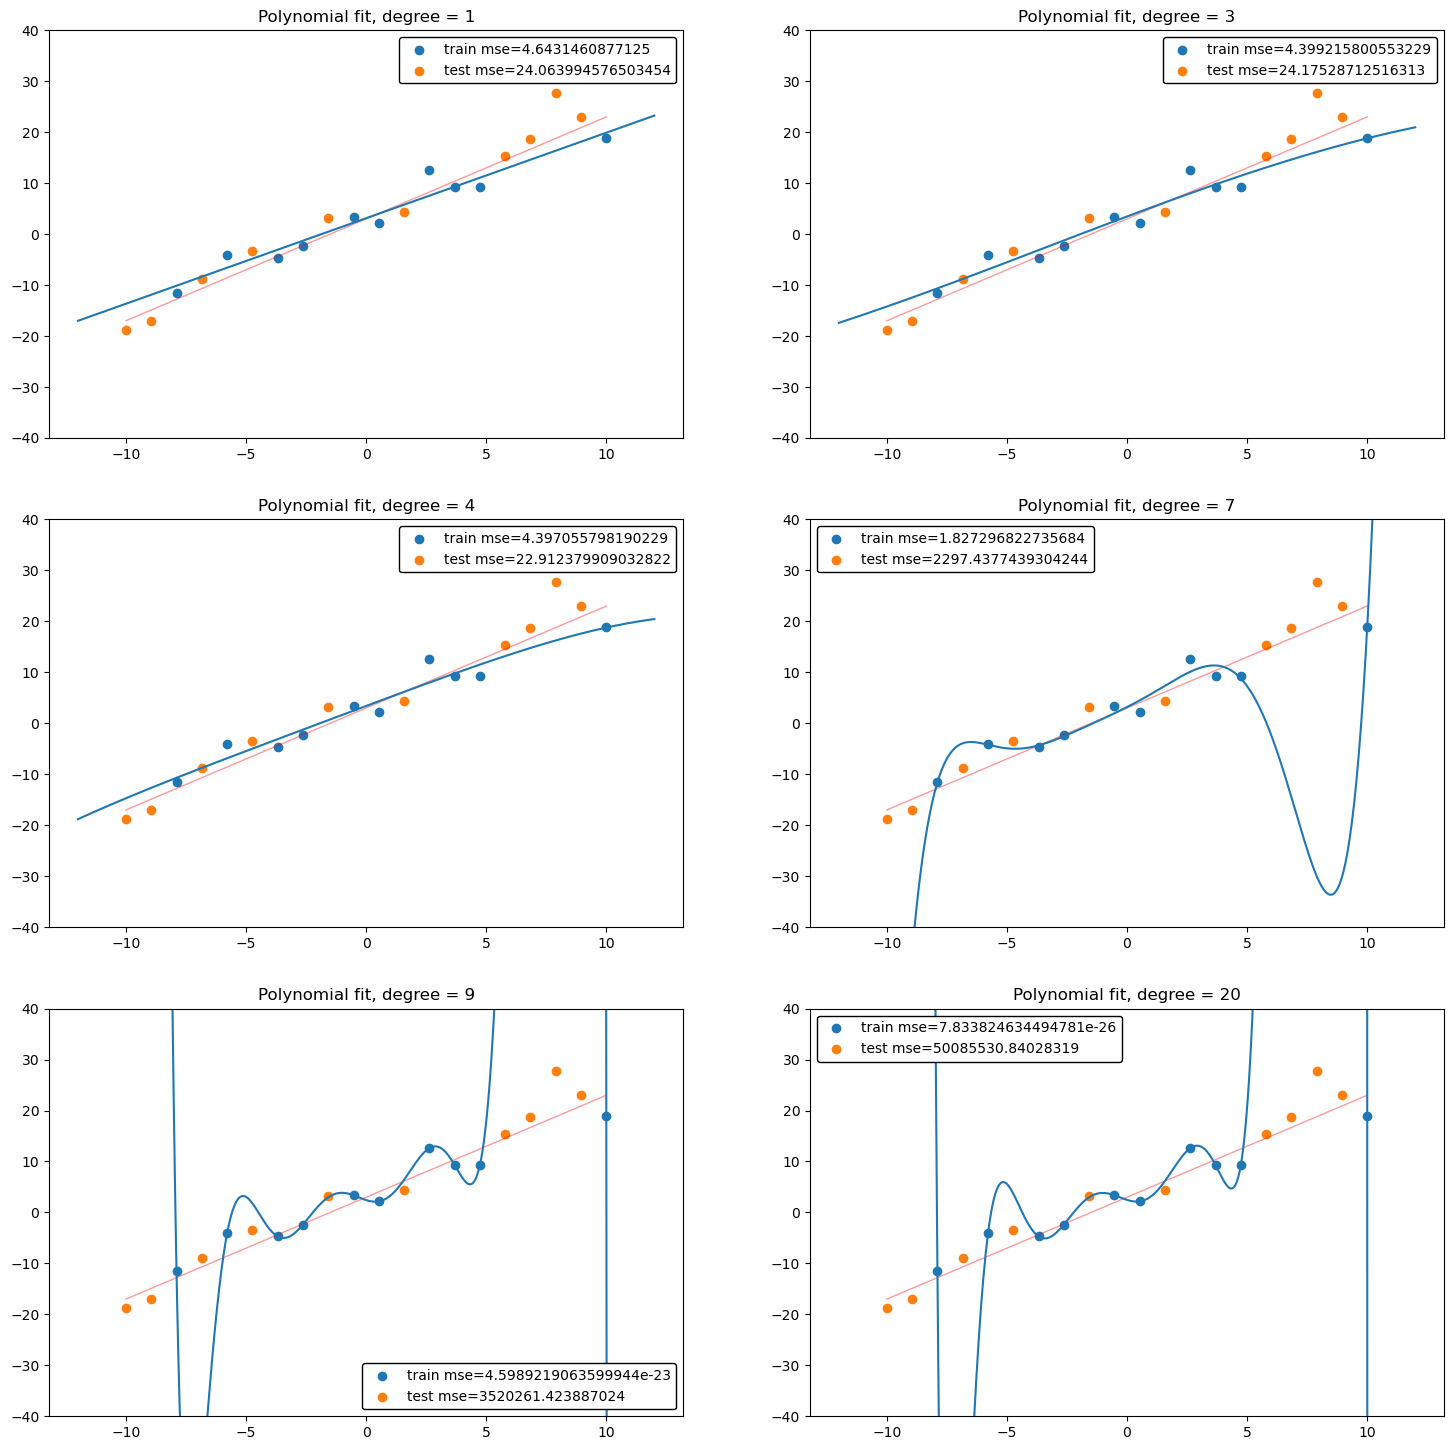

In [99]:
grid = np.linspace(-12, 12, 500)

fig, ax = plt.subplots(3, 2, figsize=(18,18))
ax = ax.ravel()

for i, deg in enumerate([1,3,4,7,9,20]):
    poly = np.polyfit(X_train, y_train, deg)
    ax[i].set_title('Polynomial fit, degree = ' + str(deg))
    ax[i].scatter(X_train, y_train, label=f'train mse={mean_squared_error(y_train, np.polyval(poly, X_train))}')
    ax[i].scatter(X_test, y_test, label=f'test mse={mean_squared_error(y_test, np.polyval(poly, X_test))}')
    ax[i].set_ylim(-40, 40)
    ax[i].plot(X, 2 * X + 3, color='red', lw=1, alpha = 0.4)
    ax[i].plot(grid, np.polyval(poly, grid))
    legend_box = ax[i].legend(framealpha=1).get_frame()
    legend_box.set_facecolor("white")
    legend_box.set_edgecolor("black")
    
plt.show()

# PipeLine Решения задачи

In [101]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'
columns = ('age workclass fnlwgt education educ-num marital-status occupation relationship '
           'race sex capital-gain capital-loss  hours-per-week native-country salary')

df = pd.read_csv(url, sep=', ')
df.columns = columns.split()
df.head()

,age,workclass,fnlwgt,education,educ-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary
0,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
1,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
2,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
3,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
4,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K


In [102]:
df.shape

(32560, 15)

In [103]:
numeric_indices = np.array([0, 2, 4, 10, 11, 12])
categorical_indices = np.array([1, 3, 5, 6, 7, 8, 9, 13])
df = df.replace('?', np.nan)
df = df.dropna()
df['salary'] = df['salary'].apply((lambda x: x=='>50k'))

In [104]:
numeric_data = df[df.columns[numeric_indices]]
categorial_data = df[df.columns[categorical_indices]]

categorial_data.head()

,workclass,education,marital-status,occupation,relationship,race,sex,native-country
0,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,United-States
1,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,United-States
2,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,United-States
3,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,Cuba
4,Private,Masters,Married-civ-spouse,Exec-managerial,Wife,White,Female,United-States


In [105]:
df['education'].unique(), len(df['education'].unique())

(array(['Bachelors', 'HS-grad', '11th', 'Masters', '9th', 'Some-college',
        'Assoc-acdm', '7th-8th', 'Doctorate', 'Assoc-voc', 'Prof-school',
        '5th-6th', '10th', 'Preschool', '12th', '1st-4th'], dtype=object),
 16)

### One-Hot-Encoding

In [107]:
dummy_features = pd.get_dummies(categorial_data)

In [108]:
X = pd.concat([numeric_data, dummy_features], axis=1)
X_origin = df.iloc[:, :-1]
X.head()

,age,fnlwgt,educ-num,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,50,83311,13,0,0,13,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,38,215646,9,0,0,40,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
2,53,234721,7,0,0,40,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
3,28,338409,13,0,0,40,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4,37,284582,14,0,0,40,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False


In [109]:
y = df['salary']

In [110]:
X.shape, X_origin.shape

((30161, 104), (30161, 14))

In [131]:
X_train, X_test, y_train, y_test = train_test_split(X.values, y.values, train_size=0.8,random_state=42)

In [133]:
def search_and_draw(X, y, model, param_name, grid, param_scale='ordinary', draw=True):
    """
    Выполняет поиск по сетке гиперпараметров модели и визуализирует результаты.

    Параметры:
    ----------
    X : array-like of shape (n_samples, n_features)
        Обучающие данные. Матрица признаков.
    y : array-like of shape (n_samples,)
        Целевые значения для обучающих данных.
    model : estimator object
        Экземпляр модели машинного обучения, который будет использоваться для поиска по сетке.
    param_name : str
        Название параметра модели, который будет изменяться в процессе поиска по сетке.
    grid : array-like
        Сетка значений для параметра, который будет исследован.
    param_scale : {'ordinary', 'log'}, optional (default='ordinary')
        Определяет шкалу для оси x на графике. Если 'log', то используется логарифмическая шкала.
    draw : bool, optional (default=True)
        Флаг, указывающий, нужно ли строить график результатов поиска по сетке.

    Возвращает:
    -----------
    means : ndarray of shape (len(grid),)
        Средние значения метрики качества модели для каждого значения параметра из сетки.
    error : ndarray of shape (len(grid),)
        Стандартные отклонения метрики качества модели для каждого значения параметра из сетки.

    Примечания:
    ------------
    Функция использует GridSearchCV для выполнения кросс-валидации с использованием метрики F1.
    Если флаг draw установлен в True, то строится график зависимости среднего значения метрики
    качества модели от значения параметра. На графике также показаны интервалы ошибок.
    """
    parameters = {param_name: grid}

    CV_model = GridSearchCV(estimator=model,
                            param_grid=parameters,
                            cv=5,
                            scoring='f1',
                            n_jobs=-1,
                            verbose=10)
    CV_model.fit(X, y)
    means = CV_model.cv_results_['mean_test_score']
    error = CV_model.cv_results_['std_test_score']

    if draw:
        plt.figure(figsize=(15,8))
        plt.title('choose ' + param_name)


        if (param_scale == 'log'):
            plt.xscale('log')

        plt.plot(grid, means, label='mean values of score', color='red', lw=3)

        plt.fill_between(grid, means - 2 * error, means + 2 * error,
                         color='green', label='filled area between errors', alpha=0.5)
        legend_box = plt.legend(framealpha=1).get_frame()
        legend_box.set_facecolor("white")
        legend_box.set_edgecolor("black")
        plt.xlabel('parameter')
        plt.ylabel('roc_auc')
        plt.show()

    return means, error

In [135]:
models = [KNeighborsClassifier(), DecisionTreeClassifier()]
param_names = ['n_neighbors', 'max_depth']
grids = [np.array(np.linspace(4, 30, 8), dtype='int'), np.arange(1, 30)]
param_scales = ['log', 'ordinary']

Fitting 5 folds for each of 8 candidates, totalling 40 fits


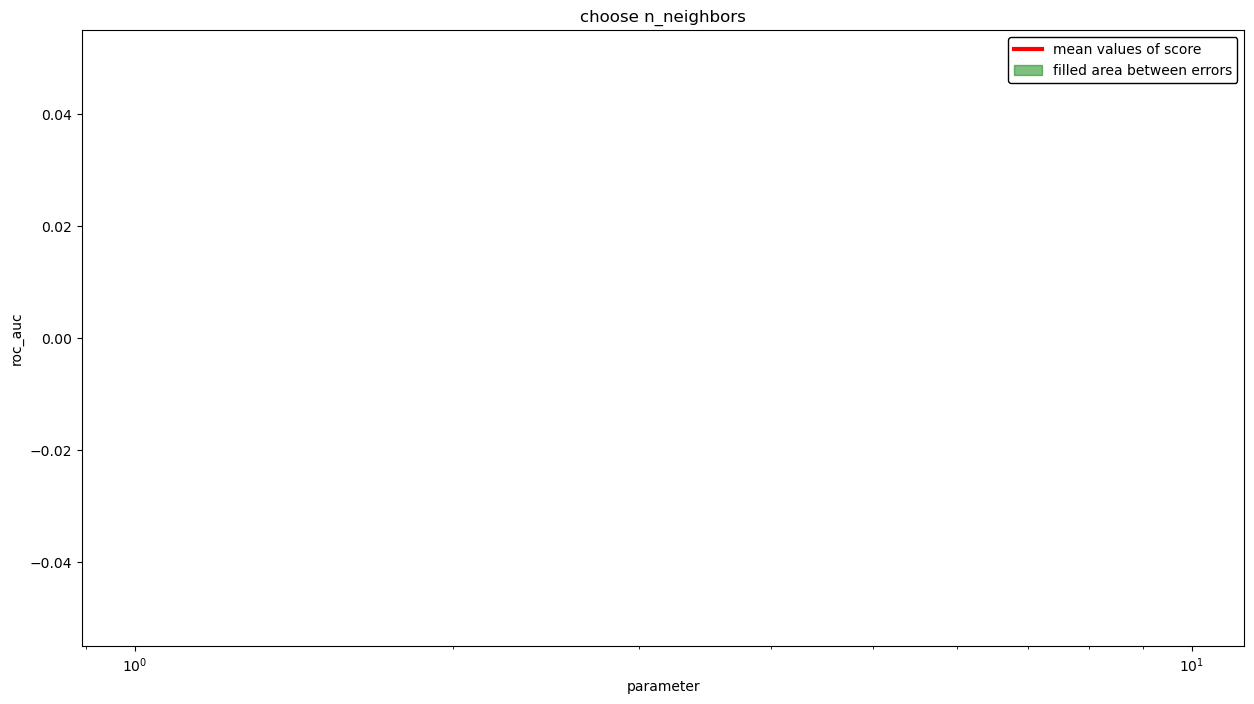

Fitting 5 folds for each of 29 candidates, totalling 145 fits


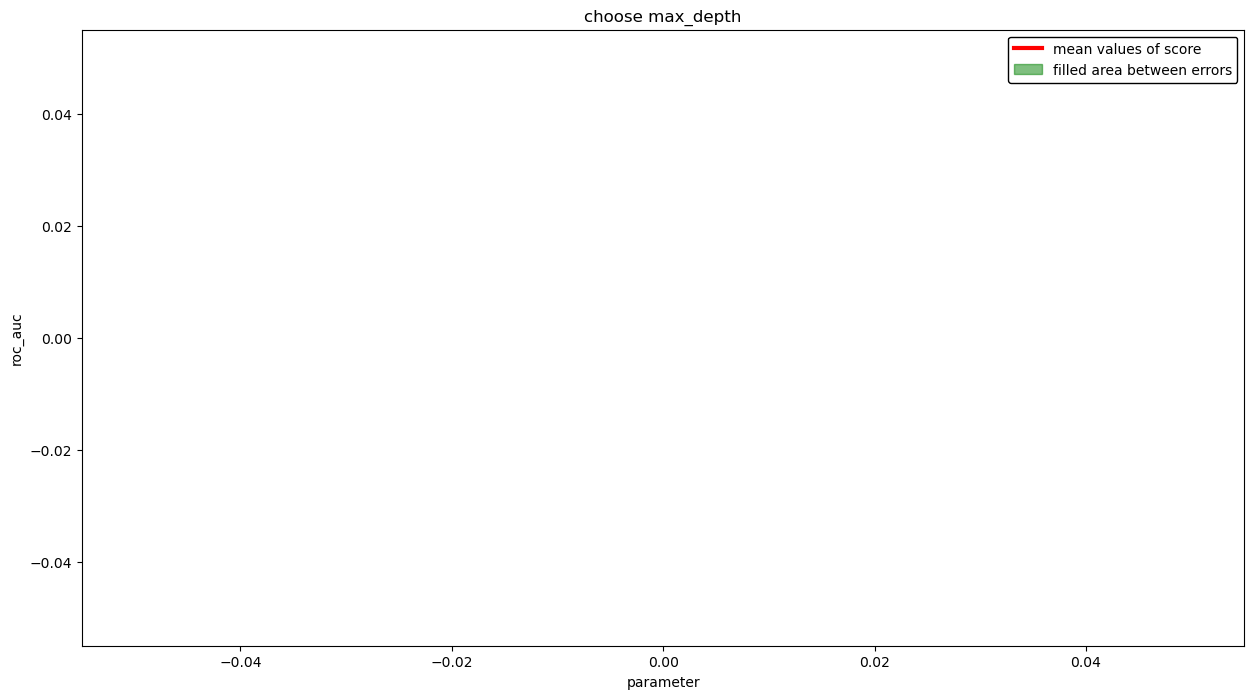

In [141]:
for model, param_name, grid, param_scale in zip(models,
                                                param_names,
                                                grids,
                                                param_scales):
    search_and_draw(X_train, y_train, model, param_name, grid, param_scale)

In [147]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [149]:
model = RandomForestClassifier(n_estimators=50, n_jobs=-1)

model.fit(X_train, y_train)
y_train_predicted = model.predict_proba(X_train_scaled)[:, 1]
y_test_predicted = model.predict_proba(X_test_scaled)[:, 1]

IndexError: index 1 is out of bounds for axis 1 with size 1